In [1]:
import torch
from torchviz import make_dot
import os
import torch.nn as nn
from FloodMLP import FloodMLP
from torch.utils.data import TensorDataset, DataLoader
from sklearn.discriminant_analysis import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import pandas as pd
import joblib

dataset_path = "datasets"
param_path = "MLP_saved_params"
results_path = "MLP_results"

In [2]:
# ----- Helper functions ----- #

def train_and_test_library_model(X,y, model):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    return y_test, y_pred

def eval_performance(y_test, y_pred, model_name):
    print("======== ", model_name, " ========")
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    print("Accuracy: ", accuracy_score(y_test, y_pred))
    print("F1 Score: ", f1_score(y_test, y_pred), "\n")

def plot_losses_vs_epoch(train_losses, val_losses):
    plt.figure(figsize=(8,5))
    plt.plot(train_losses, label="Training Loss")
    plt.plot(val_losses, label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training vs Validation Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

def split_data(X, y, test_size=0.2, val_size=0.1):
    # Split into 80% train and 20% test
    X_train_val, X_test, y_train_val, y_test = train_test_split(
        X.values, y.values, test_size=test_size, random_state=42, stratify=y
    )

    # From train_val, take 12.5% for validation → 0.8 * 0.125 = 0.10 of full data
    val_relative_size = val_size / (1 - test_size)
    X_train, X_val, y_train, y_val = train_test_split(
        X_train_val, y_train_val, test_size=val_relative_size, random_state=42, stratify=y_train_val
    )

    # Convert to torch tensors
    X_train_t = torch.tensor(X_train, dtype=torch.float32)
    y_train_t = torch.tensor(y_train.reshape(-1, 1), dtype=torch.float32)

    X_val_t = torch.tensor(X_val, dtype=torch.float32)
    y_val_t = torch.tensor(y_val.reshape(-1, 1), dtype=torch.float32)

    X_test_t = torch.tensor(X_test, dtype=torch.float32)
    y_test_t = torch.tensor(y_test.reshape(-1, 1), dtype=torch.float32)

    return X_train_t, y_train_t, X_val_t, y_val_t, X_test_t, y_test_t

def train_and_validation_MLP(X_train_t, y_train_t, X_val_t, y_val_t, batch_size, dropout_rate, learning_rate, num_epochs):
    # DataLoaders
    train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=64, shuffle=True)
    val_loader   = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=64, shuffle=False)

    # Initialize model, optimizer, and loss criterion
    model = FloodMLP(input_size=X_train_t.size(1), dropout=dropout_rate)
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    criterion = nn.BCELoss()

    # Training and Validation Loop
    train_losses = []
    val_losses = []

    for epoch in range(num_epochs):
        # Training
        model.train()
        epoch_train_loss = 0.0
        for xb, yb in train_loader:
            optimizer.zero_grad()
            preds = model(xb)
            loss = criterion(preds, yb)
            loss.backward()
            optimizer.step()
            epoch_train_loss+=loss.item()

        # Validation
        model.eval()
        epoch_val_loss = 0.0
        with torch.no_grad():
            for xb, yb in val_loader:
                val_preds = model(xb)
                val_loss = criterion(val_preds, yb)
                epoch_val_loss += val_loss.item()

        # Average losses
        avg_train_loss = epoch_train_loss / len(train_loader)
        avg_val_loss   = epoch_val_loss / len(val_loader)

        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)

        if ((epoch+1) % 10 == 0):
            print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

    # dot = make_dot(preds, params=dict(model.named_parameters()))
    # dot.render("mynetwork", format="png", view=False) # Saves as PNG and opens it
    plot_losses_vs_epoch(train_losses, val_losses)
    return model

def test_MLP(X_test_t, y_test_t, model):
    test_loader = DataLoader(TensorDataset(X_test_t, y_test_t))

    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for xb, yb in test_loader:
            outputs = model(xb)
            probs = outputs.squeeze(dim=1)              # shape → (batch,)
            preds = (probs >= 0.5).long()               # threshold at 0.5
            all_preds.extend(preds.numpy())
            all_labels.extend(yb.numpy())
    return all_preds, all_labels

def add_test_results(dataset_name, drop_out, lr, batch_size, num_epochs, f1, accuracy):
    csv_name = f"{dataset_name}_results.csv"
    if not os.path.exists(os.path.join(results_path, csv_name)):
        # Create the CSV file with headers if it doesn't exist
        param_idx = 0
        results_df = pd.DataFrame(columns=["Param_File", "Learning_Rate", "Batch_Size", "Num_Epochs", "Dropout_Rate", "F1_Score", "Accuracy"])
    else: 
        results_df = pd.read_csv(os.path.join(results_path, csv_name))
        param_idx = results_df.shape[0]
    
    param_file = f"{dataset_name}_params_{param_idx}.pkl"
    new_row_df = pd.DataFrame([{
        "Param_File": param_file,
        "Learning_Rate": lr,
        "Batch_Size": batch_size,
        "Num_Epochs": num_epochs,
        "Dropout_Rate": drop_out,
        "F1_Score": f1,
        "Accuracy": accuracy
    }])

    if not os.path.exists(os.path.join(results_path, csv_name)):
        results_df = new_row_df
    else:
        results_df = pd.concat([results_df, new_row_df], ignore_index=True)
    results_df.to_csv(os.path.join(results_path, csv_name), index=False)
    return param_file

In [3]:
# HYPERTUNING PARAMETERS
BATCH_SIZE = 64
NUM_EPOCHS = 60
DROPOUT_RATE = 0.1
LR = 0.0005

# Baseline Model 

In [4]:
# Load the Baseline dataset
bangladesh_floods = pd.read_csv(os.path.join(dataset_path, "floods_bangladesh.csv"), skiprows=1)

# Define the column names
bangladesh_floods.columns = ['Station_Index', 'Station_Name', 'Year', 'Month', 'Max_Temp', 
                  'Min_Temp', 'Monthly_Rainfall', 'Relative_Humidity', 'Wind_Speed',
                  'Cloud_Coverage', 'Hours_of_Sunshine', 'Station_Number',
                  'X_Coord', 'Y_Coord', 'Latitude', 'Longitude', 'Altitude',
                  'Year_Month', 'Flood']

# Prepare features and labels
bangladesh_floods['Flood'] = bangladesh_floods['Flood'].fillna(0)
X_baseline_cols = ['Max_Temp', 'Min_Temp', 'Monthly_Rainfall', 'Relative_Humidity', 'Wind_Speed',
                    'Cloud_Coverage', 'Hours_of_Sunshine']

X_baseline = bangladesh_floods[X_baseline_cols]
y_baseline = bangladesh_floods["Flood"]  

========  LOGISTIC REGRESSION, BASELINE  ========
Confusion Matrix:
[[3200   79]
 [ 128  702]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.96      0.98      0.97      3279
         1.0       0.90      0.85      0.87       830

    accuracy                           0.95      4109
   macro avg       0.93      0.91      0.92      4109
weighted avg       0.95      0.95      0.95      4109

Accuracy:  0.949622779265028
F1 Score:  0.8715083798882681 

========  RANDOM FOREST, BASELINE  ========
Confusion Matrix:
[[3214   65]
 [ 105  725]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.97      0.98      0.97      3279
         1.0       0.92      0.87      0.90       830

    accuracy                           0.96      4109
   macro avg       0.94      0.93      0.93      4109
weighted avg       0.96      0.96      0.96      4109

Accuracy:  0.958627403261134
F1 Score:  0.89506172839

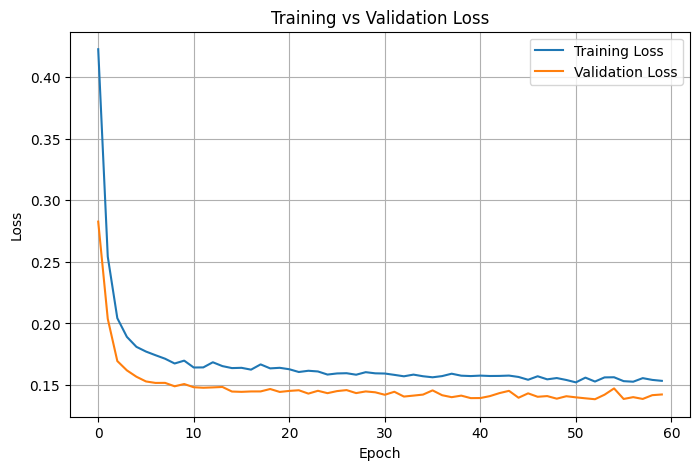

========  MLP, BASELINE  ========
Confusion Matrix:
[[3215  160]
 [  68  666]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.95      0.97      3375
           1       0.81      0.91      0.85       734

    accuracy                           0.94      4109
   macro avg       0.89      0.93      0.91      4109
weighted avg       0.95      0.94      0.95      4109

Accuracy:  0.9445120467266975
F1 Score:  0.8538461538461538 



['MLP_saved_params\\baseline_params_6.pkl']

In [5]:
# ---- Library Models ---- #
log_reg_model = LogisticRegression(max_iter=1000)
y_true, y_pred = train_and_test_library_model(X_baseline, y_baseline, log_reg_model)
eval_performance(y_true, y_pred, "LOGISTIC REGRESSION, BASELINE")

ranforest_model = RandomForestClassifier(n_estimators=100, random_state=42)
y_true, y_pred = train_and_test_library_model(X_baseline, y_baseline, ranforest_model)
eval_performance(y_true, y_pred, "RANDOM FOREST, BASELINE")

# ---- MLP Model ---- #
X_train_t, y_train_t, X_val_t, y_val_t, X_test_t, y_test_t = split_data(X_baseline, y_baseline,
                                                                         test_size=0.2, val_size=0.1)

trained_model = train_and_validation_MLP(X_train_t, y_train_t, X_val_t, y_val_t,
                                          batch_size=BATCH_SIZE, dropout_rate=DROPOUT_RATE, 
                                          learning_rate=LR, num_epochs=NUM_EPOCHS)

y_true, y_pred = test_MLP(X_test_t, y_test_t, trained_model)

eval_performance(y_true, y_pred, "MLP, BASELINE")

param_file = add_test_results("baseline", DROPOUT_RATE, LR, BATCH_SIZE, NUM_EPOCHS, 
                              f1_score(y_true, y_pred), accuracy_score(y_true, y_pred))
joblib.dump(trained_model, os.path.join(param_path, param_file))

## Augmented Dataset

In [6]:
# Load the Baseline dataset
aug_data = pd.read_csv(os.path.join(dataset_path, "floods_bangladesh_augmented.csv"))

# Prepare features and labels
aug_data['Flood'] = aug_data['Flood'].fillna(0)
X_aug_cols = ['Max_Temp', 'Min_Temp', 'Monthly_Rainfall', 'Relative_Humidity', 'Wind_Speed',
            'Cloud_Coverage', 'Hours_of_Sunshine', 'Elevation_m', 'Slope_deg', 'LC_Built-up',
            'LC_Cropland', 'LC_Permanent_water_bodies', 'LC_Tree_cover', 'HSG_C', 'HSG_D']

X_aug = aug_data[X_aug_cols]
y_aug = aug_data["Flood"]  

========  LOGISTIC REGRESSION, AUGMENTED  ========
Confusion Matrix:
[[3193   86]
 [ 115  715]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.97      0.97      0.97      3279
         1.0       0.89      0.86      0.88       830

    accuracy                           0.95      4109
   macro avg       0.93      0.92      0.92      4109
weighted avg       0.95      0.95      0.95      4109

Accuracy:  0.9510829885616938
F1 Score:  0.8767627222562845 

========  RANDOM FOREST, AUGMENTED  ========
Confusion Matrix:
[[3239   40]
 [  53  777]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.98      0.99      0.99      3279
         1.0       0.95      0.94      0.94       830

    accuracy                           0.98      4109
   macro avg       0.97      0.96      0.96      4109
weighted avg       0.98      0.98      0.98      4109

Accuracy:  0.9773667559016792
F1 Score:  0.9435336

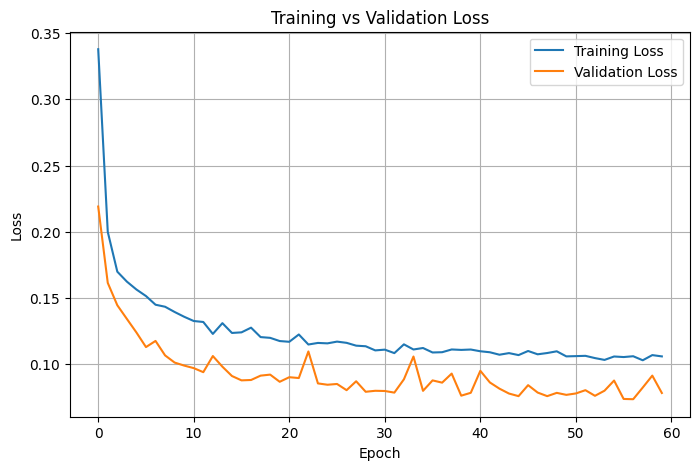

========  MLP, AUGMENTED  ========
Confusion Matrix:
[[3182   48]
 [ 101  778]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      3230
           1       0.94      0.89      0.91       879

    accuracy                           0.96      4109
   macro avg       0.96      0.94      0.94      4109
weighted avg       0.96      0.96      0.96      4109

Accuracy:  0.9637381357994645
F1 Score:  0.9126099706744868 



['MLP_saved_params\\augmented_params_6.pkl']

In [7]:
# ---- Library Models ---- #
y_true, y_pred = train_and_test_library_model(X_aug, y_aug, log_reg_model)
eval_performance(y_true, y_pred, "LOGISTIC REGRESSION, AUGMENTED")

y_true, y_pred = train_and_test_library_model(X_aug, y_aug, ranforest_model)
eval_performance(y_true, y_pred, "RANDOM FOREST, AUGMENTED")

# ---- MLP Model ---- #
X_train_t, y_train_t, X_val_t, y_val_t, X_test_t, y_test_t = split_data(X_aug, y_aug,
                                                                         test_size=0.2, val_size=0.1)

trained_model = train_and_validation_MLP(X_train_t, y_train_t, X_val_t, y_val_t,
                                          batch_size=BATCH_SIZE, dropout_rate=DROPOUT_RATE, 
                                          learning_rate=LR, num_epochs=NUM_EPOCHS)

y_true, y_pred = test_MLP(X_test_t, y_test_t, trained_model)

eval_performance(y_true, y_pred, "MLP, AUGMENTED")

param_file = add_test_results("augmented", DROPOUT_RATE, LR, BATCH_SIZE, NUM_EPOCHS, 
                              f1_score(y_true, y_pred), accuracy_score(y_true, y_pred))
joblib.dump(trained_model, os.path.join(param_path, param_file))